In [1]:
import torch
from tqdm import tqdm
import timm
import os
import torch.nn as nn
from torchsummary import summary
from torchvision import transforms
import time
from torch.utils.data import DataLoader
import torch.nn.functional as F
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
class config:
    model1 = "resnet18"
    model2 = "resnet18"
    batchsize = 32
    WEIGHT_DECAY = 0.01
    EPOCHS = 20
class path:
    maindir = "/kaggle/input/datasets/saxenaitis/deeplensetask0/dataset/train"
    valid = "/kaggle/input/datasets/saxenaitis/deeplensetask0/dataset/val"


train_data = {}
for i in (range(len(os.listdir(path.maindir)))):
    for j in tqdm(os.listdir(os.path.join(path.maindir,os.listdir(path.maindir)[i]))):
        train_data[os.path.join(os.path.join(path.maindir,os.listdir(path.maindir)[i],j))]=i
        
valid_data = {}
for i in (range(len(os.listdir(path.valid)))):
    for j in tqdm(os.listdir(os.path.join(path.valid,os.listdir(path.valid)[i]))):
        valid_data[os.path.join(os.path.join(path.valid,os.listdir(path.valid)[i],j))]=i


100%|██████████| 2500/2500 [00:01<00:00, 1736.77it/s]


In [4]:
imgtrans = transforms.Compose([
    transforms.ToPILImage(mode='L'),
    transforms.ToTensor(),
    transforms.Normalize((0.5,),(0.5,))
]
)

class CustomDataset():
    def __init__(self,dictt,trans):
        self.trans = trans
        self.dic = dictt
    def __len__(self):
        return len(self.dic)
    def __getitem__(self,idx):
        keys = list(self.dic)[idx]
        data = np.load(keys)
        data = torch.tensor(data)
        data = self.trans(data)
        values = list(self.dic.values())[idx]
        return {
            "data":torch.tensor(data,dtype = torch.float32),
            "value":torch.tensor(values)
        }

    
            

In [5]:

import numpy as np
def deltamat(shape):
    kk = np.zeros((shape,shape))
    for i in range(shape):
        for j in range(shape):
            kk[i][j] = (((i+1)**2)+((j+1)**2))**0.5
    return torch.tensor(kk,dtype = torch.float32)
positiontensor = deltamat(150)
positiontensor = positiontensor.unsqueeze(dim=0)
positiontensor = positiontensor.to(device)

In [ ]:
class PINNModel(nn.Module):
    def __init__(self,positionmat,batchsize = config.batchsize):
        super(PINNModel,self).__init__()
        self.positionmat = positionmat
        self.batchsize = batchsize
        self.encoder = timm.create_model(
            config.model1,
            pretrained = True,
            drop_rate = 0.1
        )
        self.encoder.conv1 = nn.Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
        self.encoder.fc = nn.Linear(512,150*150,bias=True)
        
        self.decoder = timm.create_model(
            config.model2,
            pretrained = True,
            drop_rate = 0.1
        )
        self.decoder.conv1 = nn.Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
        self.decoder.fc = nn.Linear(in_features=512, out_features=3, bias=True)
    
    def lensingequation(self,angular,image):
        sourcedimage = image-angular
        return sourcedimage
    
    def forward(self,x):
        k = self.encoder(x)
        #print(k.shape)
        batch = k.shape[0]
        k = k.reshape(batch,1,150,150)
        angulardistort = k*self.positionmat
        #print(angulardistort.shape)
        sourced_image = self.lensingequation(x,angulardistort)
        # twochannelimg = torch.cat((x,sourced_image),dim=1)
        features = self.decoder(sourced_image)
        return features
        

In [ ]:
#testing the model for a random tensor of shape (batch,channel,150,150)
simple = PINNModel(positiontensor,32).to(device)
xx = torch.randn(size=(45,1,150,150)).to(device)
simple(xx)

model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

tensor([[-1.2097e-01,  1.5282e-02,  2.1655e-01],
        [-2.9198e-02,  2.4970e-01, -3.3636e-02],
        [-8.2830e-02,  4.5787e-02,  9.7053e-02],
        [-8.2719e-02,  2.8240e-02, -1.4827e-02],
        [-7.0254e-02,  1.7355e-01,  9.1678e-02],
        [-2.6469e-01,  1.8494e-01,  2.4047e-01],
        [-6.1834e-02, -2.6230e-01,  6.3003e-02],
        [ 5.2492e-03, -1.2659e-01,  2.9752e-02],
        [-3.2136e-02,  6.2908e-02, -2.9537e-01],
        [ 1.9255e-02, -1.4462e-01,  1.5669e-02],
        [ 1.5653e-01,  6.2122e-02,  5.5806e-02],
        [-4.4656e-02,  1.7615e-01,  8.1346e-02],
        [ 8.0758e-02,  1.8087e-01,  1.0120e-02],
        [-5.8358e-02, -5.4555e-02, -2.5750e-02],
        [-3.4151e-02,  1.1528e-01,  2.7778e-01],
        [ 1.0541e-01, -9.8196e-02, -1.2580e-01],
        [-1.8299e-01, -9.9815e-02,  8.8533e-02],
        [ 6.4392e-02,  1.3225e-01,  4.4342e-02],
        [-2.1648e-01,  1.1842e-01, -2.3958e-01],
        [-3.7423e-03, -1.7783e-02,  1.3692e-01],
        [ 2.3466e-01

In [8]:
traindataset = CustomDataset(train_data,imgtrans)
validdataset  =CustomDataset(valid_data,imgtrans)

trainloader = DataLoader(traindataset,batch_size = 32,shuffle = True)
testloader = DataLoader(validdataset,batch_size = 32,shuffle = True)


In [ ]:
from torch.optim.lr_scheduler import OneCycleLR
def trainer(model,trainloader,optimizer,criterion,device):
    model.train()
    iterationloss = 0
    counter = 0
    for data in tqdm(trainloader):
        message = data['data'].to(device)
        target = data['value'].to(device).squeeze()
        optimizer.zero_grad()
        out = model(message)
        loss = criterion(F.log_softmax(out, dim=1), target)
        loss.backward()
        optimizer.step()
        iterationloss+=loss.item()*message.shape[0]
        counter+=message.shape[0]
    return iterationloss/counter

def tester(model, testloader, criterion, device):
    model.eval()
    iteration_loss = 0
    counter = 0
    correct_predictions = 0
    y_true = []
    y_scores = []

    for data in tqdm(testloader):
        message = data['data'].to(device)
        target = data['value'].to(device).squeeze()
        
        with torch.no_grad():
            out = model(message)
            loss = criterion(F.log_softmax(out, dim=1), target)
            iteration_loss += loss.item() * message.shape[0]
            
            predicted_classes = torch.argmax(F.log_softmax(out, dim=1), dim=1)
            correct_predictions += (predicted_classes == target).sum().item()
            
            # Append the labels and probabilities to the list
            y_true.extend(target.cpu().numpy())
            y_scores.extend(F.softmax(out, dim=1).cpu().numpy())  # Probabilities for each class

        counter += message.shape[0]

    accuracy = correct_predictions / counter
    print("Accuracy:", accuracy)
    
    y_true = np.array(y_true)
    y_scores = np.array(y_scores)
    
    # calculating ROC AUC 
    roc_auc_scores = []
    false_positive_rate = dict()
    true_positive_rate = dict()
    for i in range(y_scores.shape[1]):
        false_positive_rate[i], true_positive_rate[i], _ = roc_curve(y_true == i, y_scores[:, i])
        roc_auc_scores.append(roc_auc_score(y_true == i, y_scores[:, i]))

    # calcuating average ROC AUC across all the classes by one vs all method and taking mean of the 3 classes
    roc_score = np.mean(roc_auc_scores)
    print("ROC AUC Score:", roc_score)
    
    plt.figure(figsize=(8, 6))
    class_dict = {0:"no substructure",1:"spherical substructure",2:"vortex substructure"}
    for i in range(y_scores.shape[1]):
        plt.plot(false_positive_rate[i], true_positive_rate[i], label=f'Class {class_dict[i]} (ROC AUC = {roc_auc_scores[i]:.2f})')

    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve for Multi-Class Classification')
    plt.legend(loc="lower right")
    plt.show()
    
    return iteration_loss / counter

model = SimpleModel(positiontensor,config.batchsize)
model.to(device)
optimizer = torch.optim.RAdam(model.parameters(),lr = 0.005)
criterion = nn.CrossEntropyLoss()
scheduler = scheduler = OneCycleLR(
        optimizer,
        max_lr=0.01,
        epochs=config.EPOCHS,
        steps_per_epoch=938,
        pct_start=0.1,
        anneal_strategy="cos",
        final_div_factor=100)


Epoch no. = 1
--------------------------------------------------------------------------------


100%|██████████| 235/235 [01:23<00:00,  2.82it/s]


Accuracy: 0.33266666666666667
ROC AUC Score: 0.5066504799999999


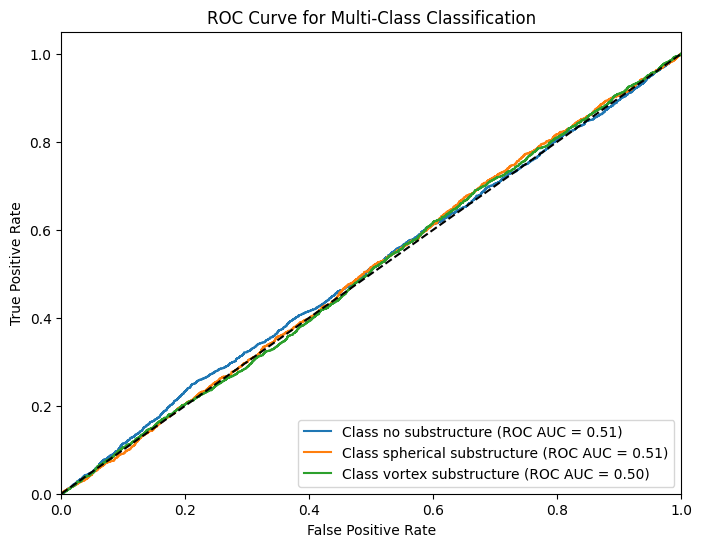

TrainLoss =  1.1016817015329996   ValidationLoss =  1.0991466985702514
lr =  0.0004000081399106875
Best Model Saved
Epoch no. = 2
--------------------------------------------------------------------------------


100%|██████████| 235/235 [00:16<00:00, 14.04it/s]


Accuracy: 0.3484
ROC AUC Score: 0.5139201999999999


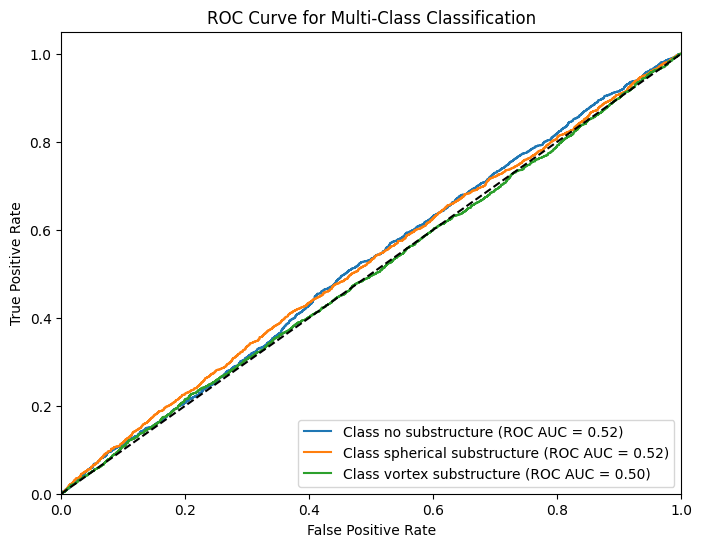

TrainLoss =  1.0989059120178222   ValidationLoss =  1.0978036218643188
lr =  0.000400008120030099
Best Model Saved
Epoch no. = 3
--------------------------------------------------------------------------------


100%|██████████| 235/235 [00:17<00:00, 13.16it/s]


Accuracy: 0.34826666666666667
ROC AUC Score: 0.5181404933333333


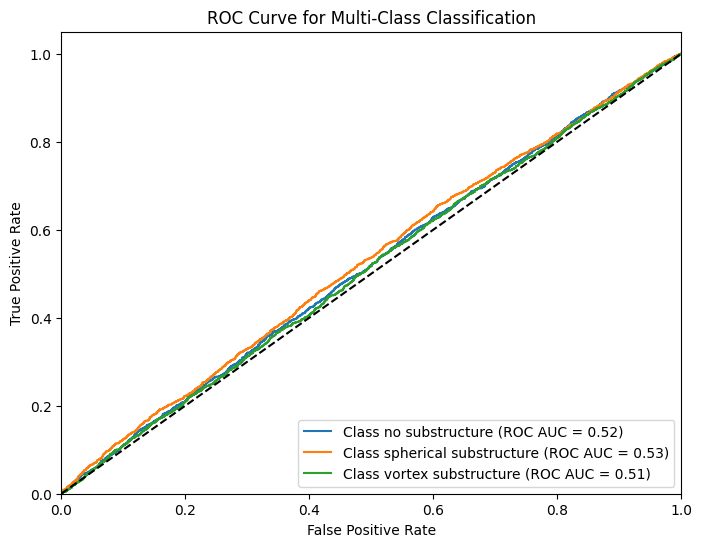

TrainLoss =  1.0981243487040202   ValidationLoss =  1.0977285182317098
lr =  0.000400008118919111
Best Model Saved
Epoch no. = 4
--------------------------------------------------------------------------------


100%|██████████| 235/235 [00:17<00:00, 13.71it/s]


Accuracy: 0.3604
ROC AUC Score: 0.5321085600000001


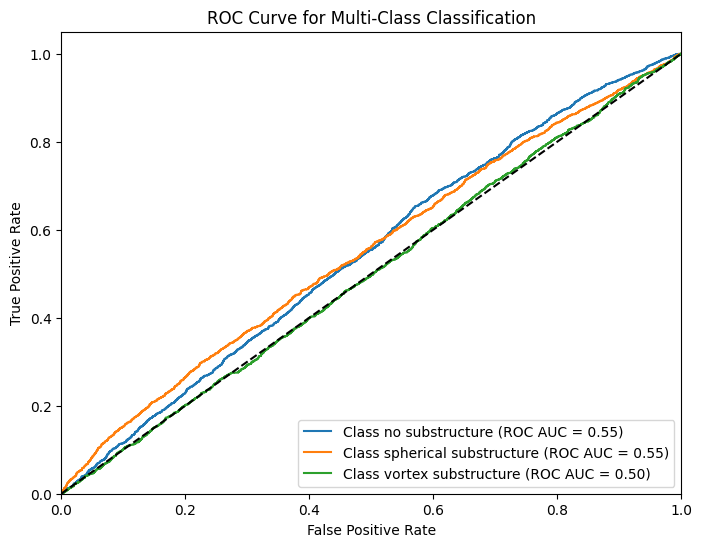

TrainLoss =  1.0964451287587484   ValidationLoss =  1.0951653554280598
lr =  0.00040000808104852757
Best Model Saved
Epoch no. = 5
--------------------------------------------------------------------------------


100%|██████████| 235/235 [00:17<00:00, 13.66it/s]


Accuracy: 0.35933333333333334
ROC AUC Score: 0.62008056


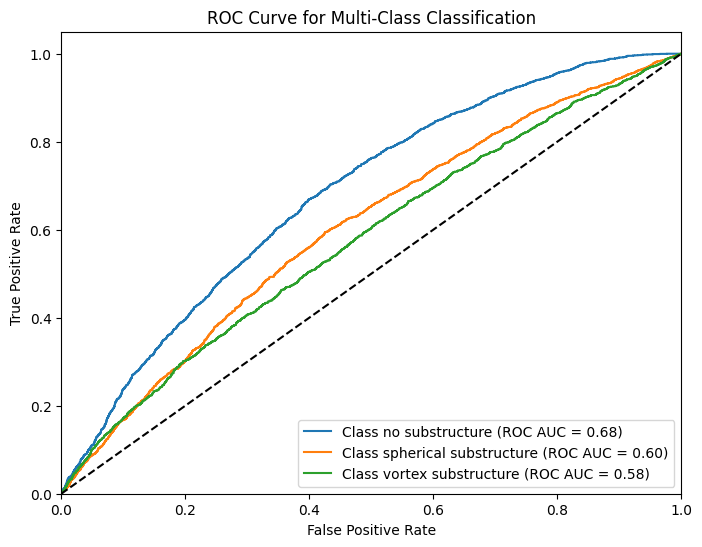

TrainLoss =  1.0772966952006022   ValidationLoss =  1.2178275719324747
lr =  0.0004000099926320718
Epoch no. = 6
--------------------------------------------------------------------------------


100%|██████████| 235/235 [00:16<00:00, 14.60it/s]


Accuracy: 0.4516
ROC AUC Score: 0.74989268


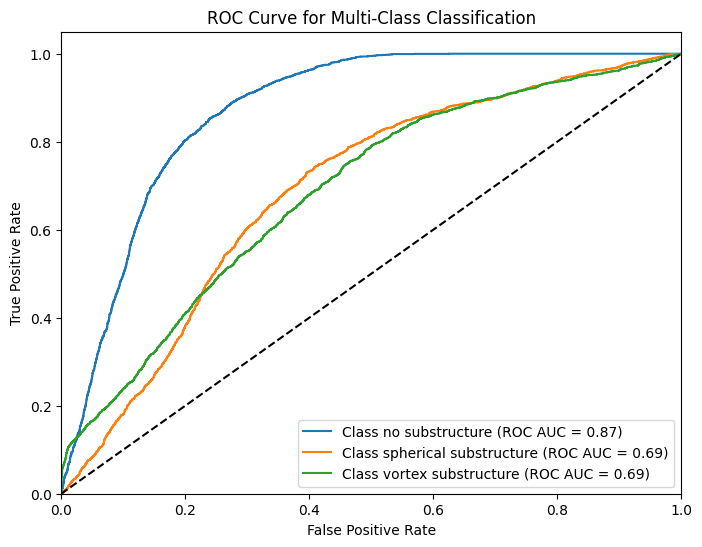

TrainLoss =  0.8894423809369405   ValidationLoss =  1.235268955675761
lr =  0.00040001028090490276
Epoch no. = 7
--------------------------------------------------------------------------------


100%|██████████| 235/235 [00:15<00:00, 15.31it/s]


Accuracy: 0.8
ROC AUC Score: 0.9314695333333333


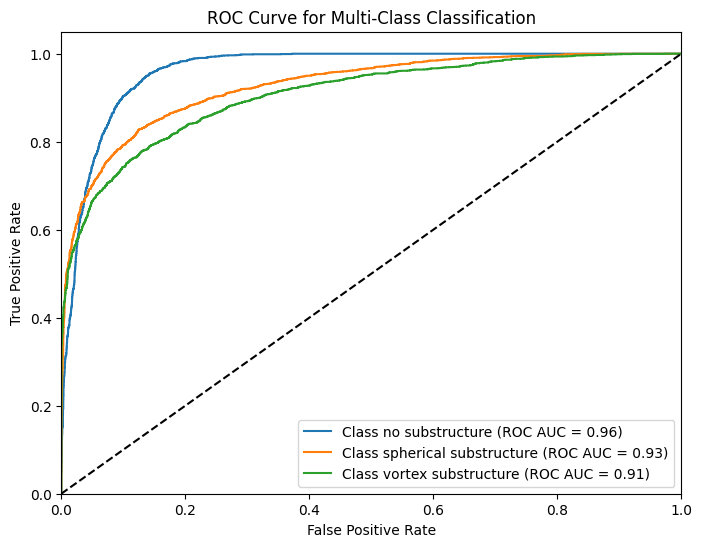

TrainLoss =  0.6382689311027527   ValidationLoss =  0.4999189371585846
lr =  0.0004000016838662558
Best Model Saved
Epoch no. = 8
--------------------------------------------------------------------------------


100%|██████████| 235/235 [00:15<00:00, 14.77it/s]


Accuracy: 0.8554666666666667
ROC AUC Score: 0.9622066933333332


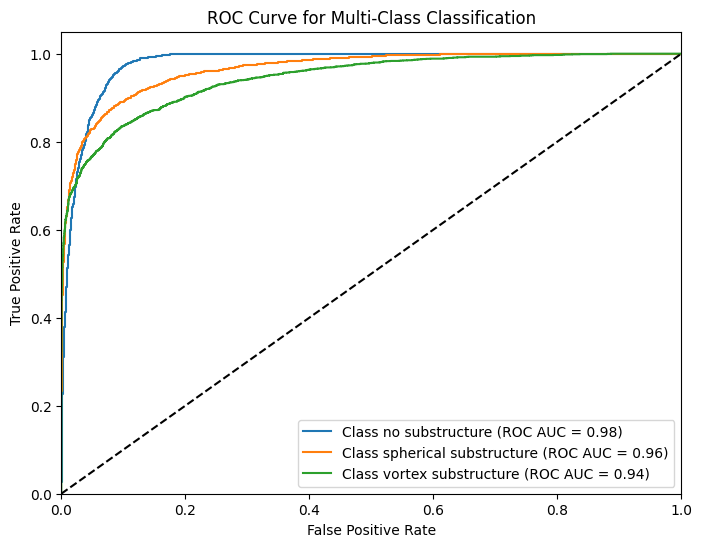

TrainLoss =  0.358128202855587   ValidationLoss =  0.35814590255419415
lr =  0.00040000086422813975
Best Model Saved
Epoch no. = 10
--------------------------------------------------------------------------------


100%|██████████| 235/235 [00:15<00:00, 15.16it/s]


Accuracy: 0.6850666666666667
ROC AUC Score: 0.9395797200000001


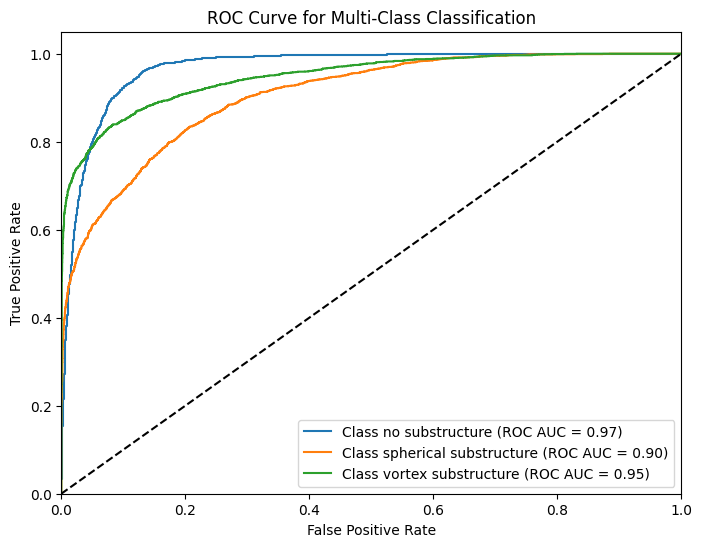

TrainLoss =  0.2978835279385249   ValidationLoss =  0.7684518445014954
lr =  0.00040000397870461335
Epoch no. = 11
--------------------------------------------------------------------------------


100%|██████████| 235/235 [00:15<00:00, 15.26it/s]


Accuracy: 0.8824
ROC AUC Score: 0.9747287733333333


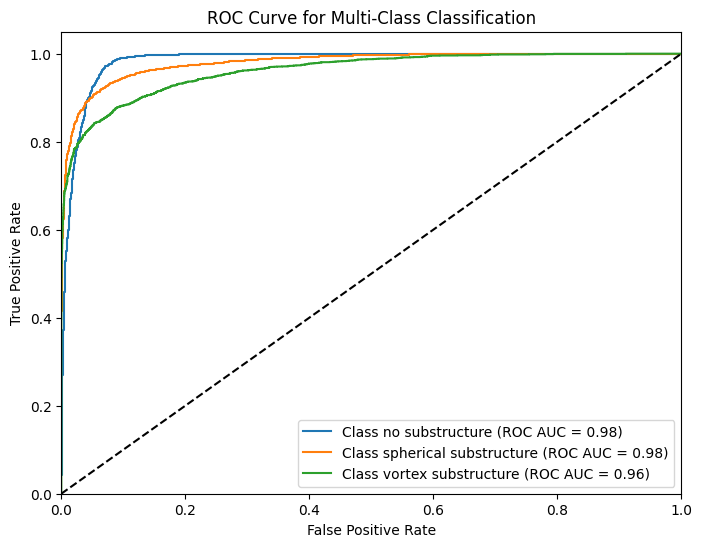

TrainLoss =  0.26274049077828726   ValidationLoss =  0.30224357651869455
lr =  0.00040000061549225543
Best Model Saved
Epoch no. = 12
--------------------------------------------------------------------------------


100%|██████████| 235/235 [00:19<00:00, 11.79it/s]


Accuracy: 0.9018666666666667
ROC AUC Score: 0.9784329333333334


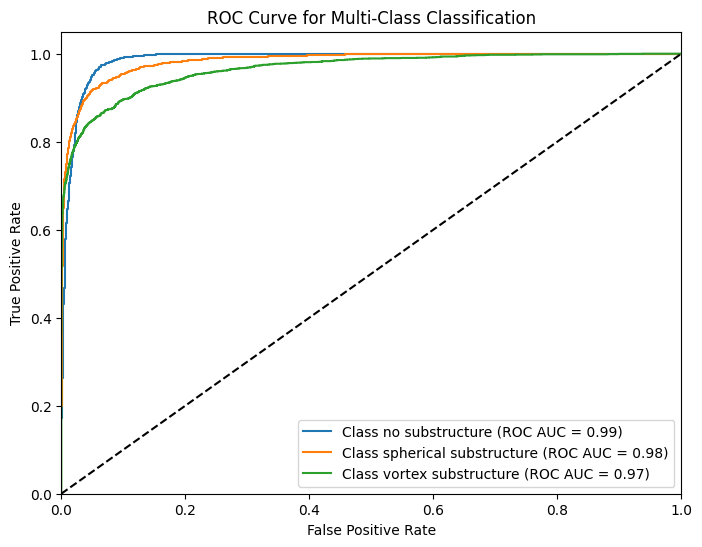

TrainLoss =  0.23211273985306421   ValidationLoss =  0.26531456218163174
lr =  0.0004000004742754134
Best Model Saved
Epoch no. = 13
--------------------------------------------------------------------------------


100%|██████████| 235/235 [00:26<00:00,  8.88it/s]

Accuracy: 0.8885333333333333
ROC AUC Score: 0.97385876


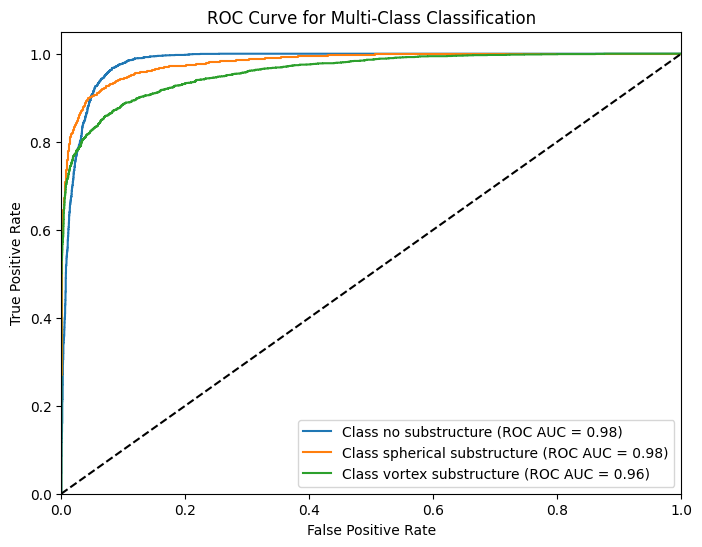

TrainLoss =  0.2025578071753184   ValidationLoss =  0.3180680095652739
lr =  0.00040000068162955767
Epoch no. = 14
--------------------------------------------------------------------------------


100%|██████████| 235/235 [00:16<00:00, 14.00it/s]


Accuracy: 0.8974666666666666
ROC AUC Score: 0.9772514


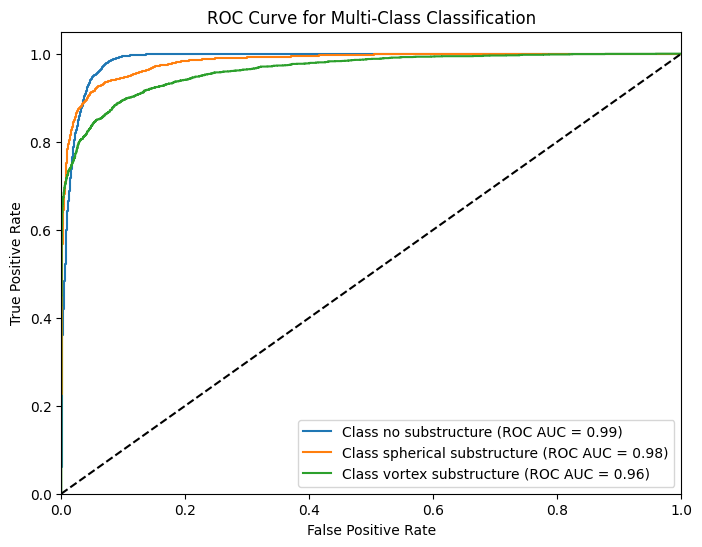

TrainLoss =  0.180863200455904   ValidationLoss =  0.2803115323384603
lr =  0.00040000052940783633
Epoch no. = 15
--------------------------------------------------------------------------------


100%|██████████| 235/235 [00:15<00:00, 14.78it/s]


Accuracy: 0.9046666666666666
ROC AUC Score: 0.9786830933333334


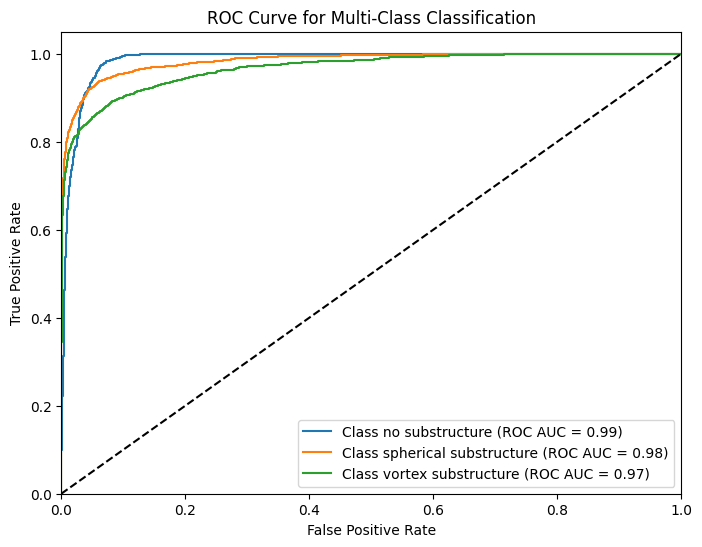

TrainLoss =  0.16208467411299546   ValidationLoss =  0.2763293502251307
lr =  0.000400000514472856
Epoch no. = 16
--------------------------------------------------------------------------------


100%|██████████| 235/235 [00:17<00:00, 13.58it/s]


Accuracy: 0.9074666666666666
ROC AUC Score: 0.97982784


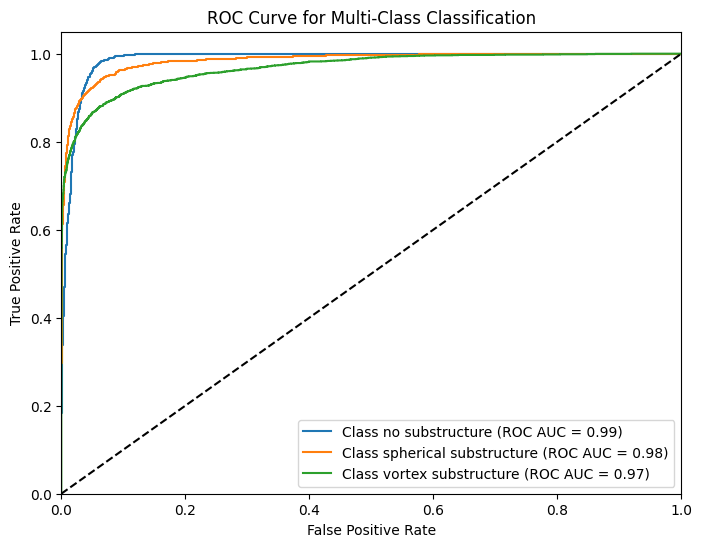

TrainLoss =  0.15280361580053967   ValidationLoss =  0.2705861968040466
lr =  0.0004000004933097639
Epoch no. = 17
--------------------------------------------------------------------------------


100%|██████████| 235/235 [00:16<00:00, 14.48it/s]


Accuracy: 0.8890666666666667
ROC AUC Score: 0.9721255599999999


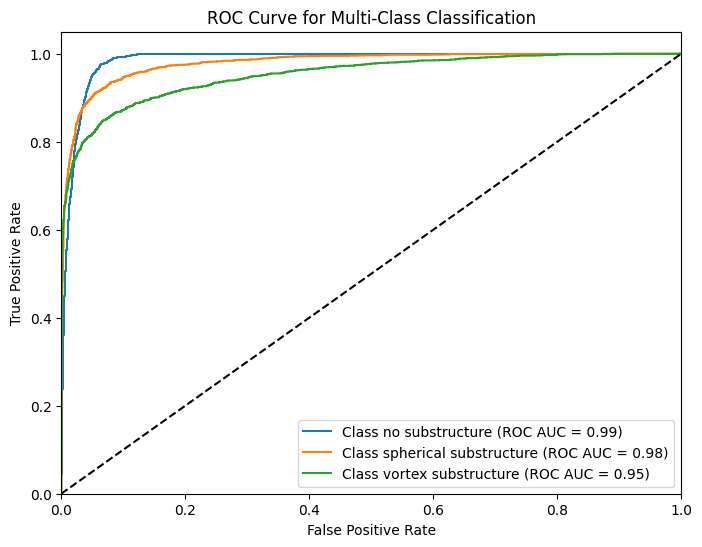

TrainLoss =  0.13470772334237893   ValidationLoss =  0.36155687222878136
lr =  0.00040000088076829095
Epoch no. = 18
--------------------------------------------------------------------------------


100%|██████████| 235/235 [00:15<00:00, 14.75it/s]


Accuracy: 0.9117333333333333
ROC AUC Score: 0.9807812399999999


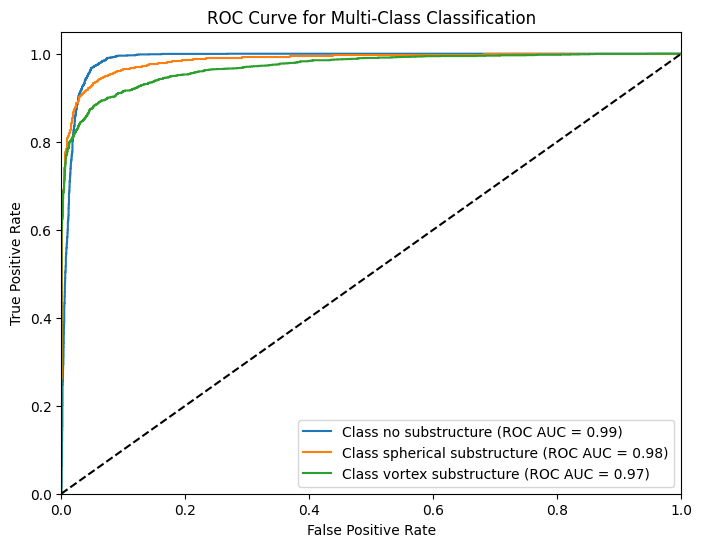

TrainLoss =  0.12023830185731252   ValidationLoss =  0.27664086362719537
lr =  0.00040000051563346753
Epoch no. = 19
--------------------------------------------------------------------------------


100%|██████████| 235/235 [00:16<00:00, 14.35it/s]


Accuracy: 0.8972
ROC AUC Score: 0.97743616


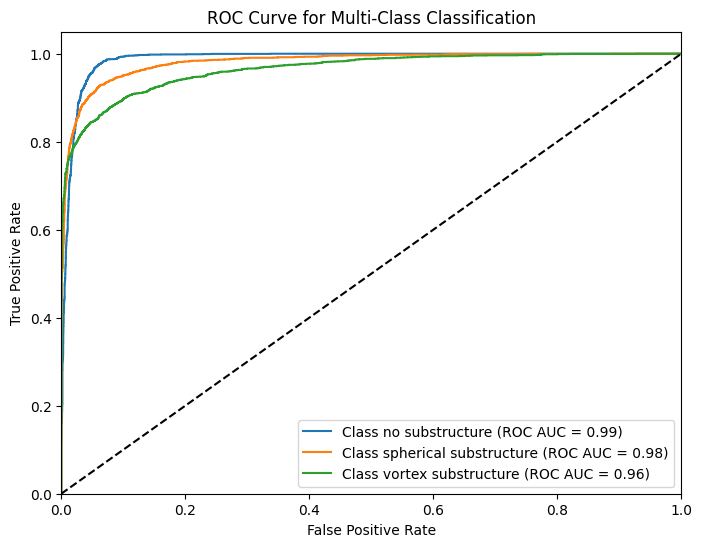

TrainLoss =  0.10636360180179279   ValidationLoss =  0.33957630539437134
lr =  0.0004000007769323199
Epoch no. = 20
--------------------------------------------------------------------------------


100%|██████████| 235/235 [00:16<00:00, 14.20it/s]


Accuracy: 0.8521333333333333
ROC AUC Score: 0.9747350666666668


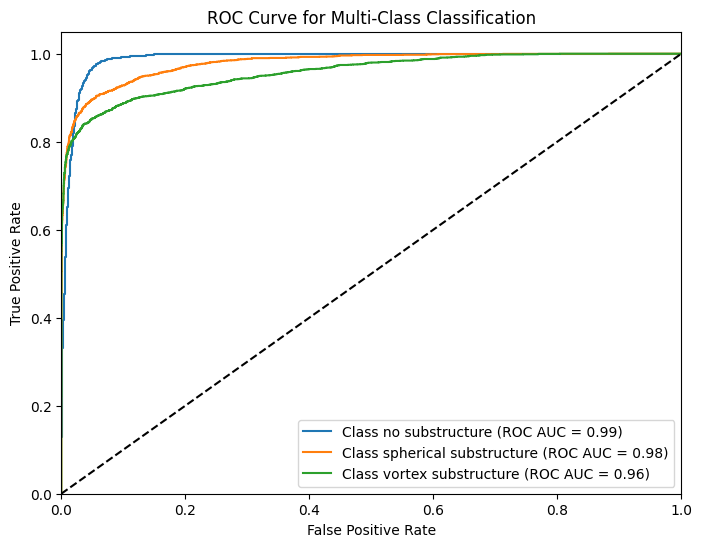

TrainLoss =  0.10231627442439398   ValidationLoss =  0.36886996541817985
lr =  0.00040000091675865615


In [ ]:
trainloss =[]
valloss = []
bestloss = np.inf
for i in range(config.EPOCHS):
    print("Epoch no. =" ,i+1)
    print("-"*80)
    trainl = trainer(model,trainloader,optimizer,criterion,device)
    vall = tester(model,testloader,criterion,device)
    trainloss.append(trainl)
    valloss.append(vall)
    scheduler.step(vall)
    print("TrainLoss = ",trainl," ","ValidationLoss = ",vall)
    lr=scheduler.get_last_lr()[0]
    print("lr = ",lr)
    if bestloss>vall:
        bestloss = vall
        torch.save({
            'model':model.state_dict(),
            'optimizer':optimizer.state_dict()},
        './Bestmodel.model'
        )
        print("Best Model Saved")
    print("="*80)